# C1 Practical 22: mantle viscosity and the ice age

*Lecture 22, with the Maxwell time from Lecture 20. Michaelmas 2026.*


> Open this notebook in Google Colab with the button on the course page, then choose *File > Save a copy in Drive*
> so that your changes are kept. Questions marked **[paper]** are answered on paper. Cells marked *run* need
> only be run; some have settings you can change, which appear as sliders and menus in Colab. A changed setting
> takes effect only when the cell is run again.


**Constants.** Mantle shear modulus $\mu = 10^{11}$ Pa, mantle density $\rho = 3300$ kg m$^{-3}$, $g = 9.8$ m s$^{-2}$,
one year $= 3.16\times10^7$ s.

In [ ]:
#@title Run this cell first. It fetches the data files and a small helper module.
import os, sys, pathlib, urllib.request
BASE = "https://raw.githubusercontent.com/da380/c1-practicals/main/"
here = pathlib.Path("../data") if pathlib.Path("../data/c1prac.py").exists() else pathlib.Path("data")
here.mkdir(exist_ok=True)
if not pathlib.Path("../data/c1prac.py").exists():          # in Colab: start from clean copies of the helper module and the data
    for old in here.glob("*"):
        if old.suffix in (".py", ".npz", ".csv", ".json"):
            old.unlink()
    urllib.request.urlretrieve(BASE + "data/c1prac.py", here / "c1prac.py")
    for m in [k for k in sys.modules if k == "c1prac"]:
        del sys.modules[m]
sys.path.insert(0, str(here))
try:
    import pyslfp
except ImportError:                       # in Colab: about a minute
    import subprocess; subprocess.run([sys.executable, "-m", "pip", "install", "-q", "pyslfp"], check=True); import pyslfp
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
_ = list(cfeature.COASTLINE.geometries())      # fetch the coastline data once, here, rather than in a results cell
from c1prac import get, global_map, synthetic_record, fit_amplitude
print("Ready.")

## 1. The Maxwell material  [paper]

The Maxwell material is the simplest model of a viscoelastic solid: one that behaves as an elastic solid when
loaded quickly and as a viscous fluid when loaded slowly. Its strain rate is the sum of an elastic part, set by the
shear modulus $\mu$, and a fluid part, set by the viscosity $\eta$,
$$ \dot\epsilon = \frac{\dot\sigma}{\mu} + \frac{\sigma}{\eta}. $$
A single time, built from these two constants, decides which behaviour is seen.

**(a)** A stress $\sigma_0$ is applied suddenly at $t = 0$ and held. Find $\epsilon(t)$ and sketch it. Which parts of the
response are elastic and which viscous?

**(b)** Instead a strain $\epsilon_0$ is imposed suddenly at $t = 0$ and held. Show that the stress decays as
$\sigma = \mu\epsilon_0\, e^{-t/\tau_M}$ and identify $\tau_M$. Explain in words what is happening inside the material.

**(c)** Now let the stress oscillate, $\sigma = \sigma_0\cos\omega t$. Write down the two contributions to $\dot\epsilon$
and show that the ratio of the viscous to the elastic strain-rate amplitude is $1/(\omega\tau_M)$. Hence say when the
material behaves as an elastic solid and when as a viscous fluid.

**(d)** Evaluate $\tau_M$ for ice ($\mu = 3\times10^9$ Pa, $\eta = 10^{14}$ Pa s) and for ordinary mantle
($\eta = 10^{21}$ Pa s). Both values are round figures, so treat the result as an order of magnitude only. Which of the following are elastic and which viscous: the tide flexing an ice shelf; the flow of an ice sheet; the
mantle's response to the annual snow load? And how would you classify the mantle's response to the last deglaciation?

## 2. Hudson Bay  [run]

The data file holds the output of a glacial isostatic adjustment calculation of the kind shown in Lecture 22: the
ICE-6G deglaciation history on a Maxwell Earth with viscosity $5\times10^{20}$ Pa s in the upper mantle and
$5\times10^{21}$ Pa s in the lower mantle. Fifty-three snapshots from 26 ka to the present are stored. Everything is
relative sea level *relative to its present value at the same place*, so a positive value in the past means sea level has fallen since.

**Cell A.** Map the change at any epoch. The hatched regions are the areas covered by ice at that epoch in the ICE-6G
reconstruction. No shoreline can form under ice, so at such places the record begins only once the ice has gone; cell B
draws that part of a site's record dashed. Remember that moving the slider does nothing until the cell is run again.

In [ ]:
#@title Cell A: relative sea level since the chosen epoch, relative to the present
age_ka = 12.0  #@param {type:"slider", min:0, max:26, step:0.5}
gia = np.load(get("gia1d_ice6g.npz"))
ages, lon, lat, rsl, ice = gia["ages"], gia["lon"], gia["lat"], gia["rsl"], gia["ice"]
k = np.abs(ages - age_ka).argmin()
fig, ax = global_map(rsl[k], lon, lat, vmin=-150, vmax=600, center=0, cmap="RdBu", contours=(0.0,),
                     label="relative sea level at that time minus present value / m", title=f"{ages[k]:g} ka: positive where sea level was higher than today (ice-covered areas hatched in white)")
ax.contourf(lon, lat, ice[k].astype(float), levels=[0.5, 1.5], colors="none", hatches=["////"], transform=ccrs.PlateCarree())
plt.show()

**Cell B.** Pick a site and plot its record. The curve is dashed while the site is under ice (hatched in cell A), when
no shoreline can form. Look at a near-field site (Richmond Gulf on the east coast of Hudson Bay, James Bay, the Ångerman
River in Sweden), a far-field site (Barbados, Tahiti) and some British sites near the edge of the former ice.

In [ ]:
#@title Cell B: the relative sea level record at a site
site = "Richmond Gulf"  #@param ["Richmond Gulf", "James Bay", "Angerman River", "Barbados", "Tahiti", "Lowestoft", "Liverpool", "NW Scotland (Arisaig)", "Oslo", "Brest", "custom"]
custom_lat = 0.0  #@param {type:"number"}
custom_lon = 0.0  #@param {type:"number"}
SITES = {"Richmond Gulf": (56.3, -76.5), "James Bay": (53.0, -80.0), "Angerman River": (62.9, 17.9), "Barbados": (13.1, -59.5),
         "Tahiti": (-17.5, -149.5), "Lowestoft": (52.5, 1.75), "Liverpool": (53.4, -3.0), "NW Scotland (Arisaig)": (56.9, -5.85),
         "Oslo": (59.9, 10.7), "Brest": (48.4, -4.5)}
la, lo = SITES.get(site, (custom_lat, custom_lon))
gia = np.load(get("gia1d_ice6g.npz")); ages, lon, lat, rsl, ice = gia["ages"], gia["lon"], gia["lat"], gia["rsl"], gia["ice"]
i, j = np.abs(lat - la).argmin(), np.abs(lon - lo).argmin()
series, covered = rsl[:, i, j], ice[:, i, j]
plt.figure(figsize=(8.45, 5.2))
plt.plot(ages, series, "--", color="0.5", label="under ice in ICE-6G: no shoreline can form")
plt.plot(ages, np.ma.masked_where(covered, series), "o-", ms=3, color="C0", label="ice-free: a record could exist")
plt.gca().invert_xaxis(); plt.axhline(0, color="k", lw=0.5); plt.grid(alpha=0.3)
plt.xlabel("age / ka"); plt.ylabel("relative sea level minus present value / m"); plt.title(f"{site}  ({la}, {lo})"); plt.legend(frameon=False); plt.show()

**Cell C.** Near the centre of a former ice sheet the uplift still to come decays exponentially with time, so
as a function of age $t$ the record is well fitted by
$$ RSL(t) = A\,(e^{t/\tau} - 1) + B , $$
where $\tau$ is the decay time (Lecture 22, section 4, where the same curve is written with time running forwards).
Real records carry errors in both height and age, and the modelled record has been given errors of the same kind:
each height is perturbed by a random error of 3 m, the indicative range of a shoreline feature, and each age by
0.15 ka, the size of radiocarbon dating and calibration errors; the present-day point is exact. The constant $B$ is an
offset needed for real records, whose datum is uncertain; here it is fixed at zero.

Choose a decay time. The cell fits the amplitude $A$ for that value, draws the curve through the data with their
error bars, and prints two measures of fit: the rms misfit, and *chi-squared*, the sum over the points of
(misfit / error)$^2$, where the timing error has been converted into an equivalent height error using the slope of
the curve. A fit is acceptable when chi-squared is about the number of points, which means that each point is off
by about one error bar on average; twice that is clearly worse. Find the best decay time for Richmond Gulf, James
Bay and the Ångerman River by trying values. The Peltier (2004) fits to the *observed* records give decay times
between about 3 and 4.5 ka. Is the model's decay faster or slower than the Earth's, and what would you change in
the model?

In [ ]:
#@title Cell C: fit a decaying exponential to a near-field record with realistic errors
site = "Richmond Gulf"  #@param ["Richmond Gulf", "James Bay", "Angerman River"]
tau_ka = 2.0  #@param {type:"slider", min:1, max:15, step:0.25}
SITES = {"Richmond Gulf": (56.3, -76.5), "James Bay": (53.0, -80.0), "Angerman River": (62.9, 17.9)}
la, lo = SITES[site]
gia = np.load(get("gia1d_ice6g.npz")); ages, lon, lat, rsl, ice = gia["ages"], gia["lon"], gia["lat"], gia["rsl"], gia["ice"]
i, j = np.abs(lat - la).argmin(), np.abs(lon - lo).argmin()
ok = ~ice[:, i, j]
t_obs, y_obs = synthetic_record(ages[ok], rsl[ok, i, j])        # heights perturbed by 3 m and ages by 0.15 ka (fixed seed)
A, rms, chi2, sig = fit_amplitude(t_obs, y_obs, tau_ka)           # best amplitude for the chosen decay time, B = 0
plt.figure(figsize=(8.45, 5.2))
plt.errorbar(t_obs, y_obs, xerr=0.15, yerr=3.0, fmt="o", ms=4, capsize=2, label="modelled record with errors")
tt = np.linspace(0, t_obs.max(), 200); plt.plot(tt, A * (np.exp(tt / tau_ka) - 1), "r-", label=f"tau = {tau_ka:.2f} ka, A = {A:.0f} m")
plt.gca().invert_xaxis(); plt.xlabel("age / ka"); plt.ylabel("RSL minus present / m"); plt.title(site); plt.legend(frameon=False); plt.show()
print(f"tau = {tau_ka:.2f} ka:  rms misfit {rms:.1f} m;  chi-squared {chi2:.1f} for {len(t_obs)} points")

**Now on paper.** The decay time is, in effect, the relaxation time of the mantle beneath the load. It is the Maxwell
time of that mantle multiplied by a geometric factor of a few, which grows with the horizontal size of the load,
because a broad load must move mantle from a greater depth. Two consequences are enough here.

**(a)** Adjust the decay time in cell C until the curve fits the Richmond Gulf data as well as you can. Then move it
up and down until the fit is clearly worse, using chi-squared as a guide, and quote the range as a rough uncertainty
on the decay time.

**(b)** A load of horizontal wavelength $\lambda$ can deform the mantle to a depth of order $\lambda/2\pi$, though a soft
upper mantle takes up much of the deformation for any load, so this is the greatest depth reached rather than where
most of the flow happens. The Laurentide ice sheet had $\lambda \approx 5000$ km and the Fennoscandian
$\lambda \approx 2000$ km. To what depths can the Richmond Gulf and the Ångerman decay times respond, and which part
of the model's two-layer viscosity does each mainly constrain? Compare with the sensitivity kernels of Lau et al.
shown in Lecture 22.

## 3. Tomography to viscosity  [paper]

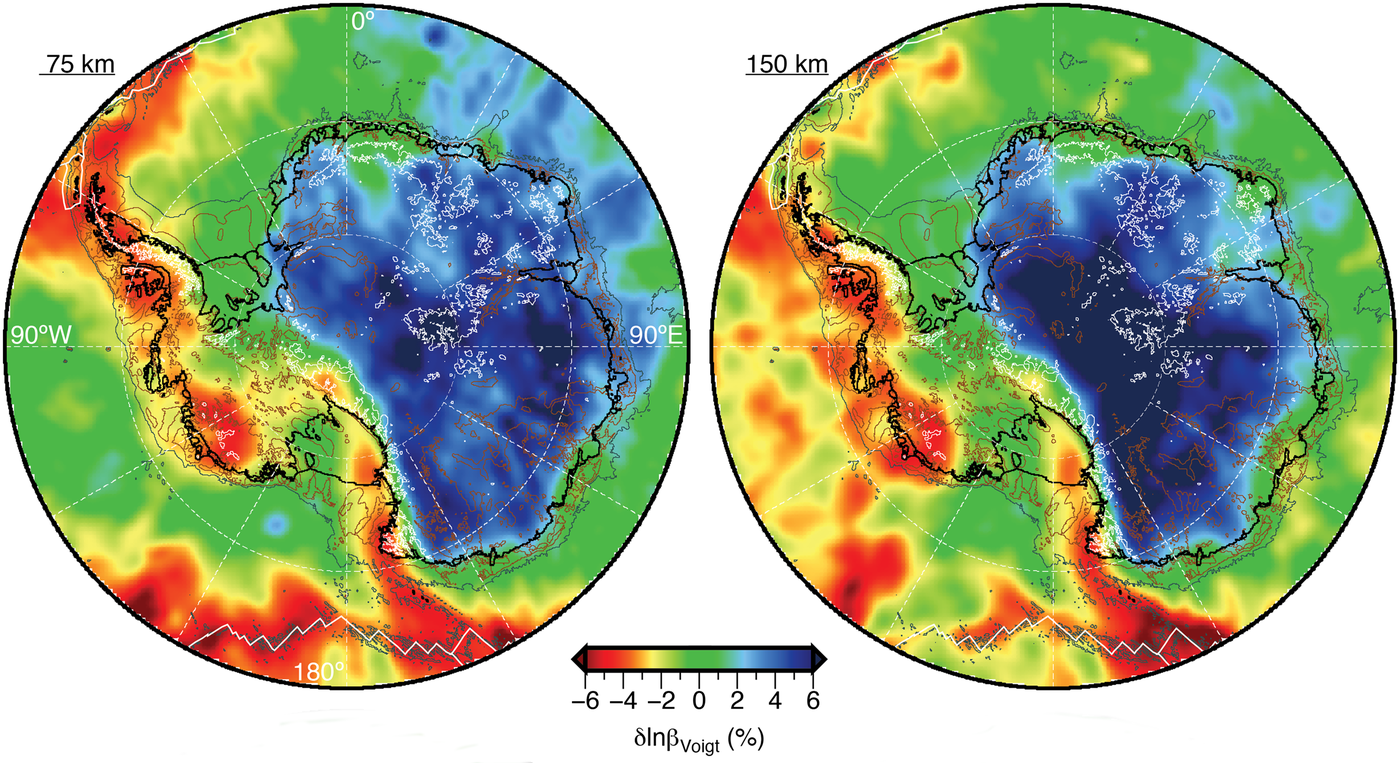<p style="font-size:90%;color:#444"><em>Voigt-averaged shear wave speed anomalies beneath Antarctica at 75 and 150 km depth.</em></p>

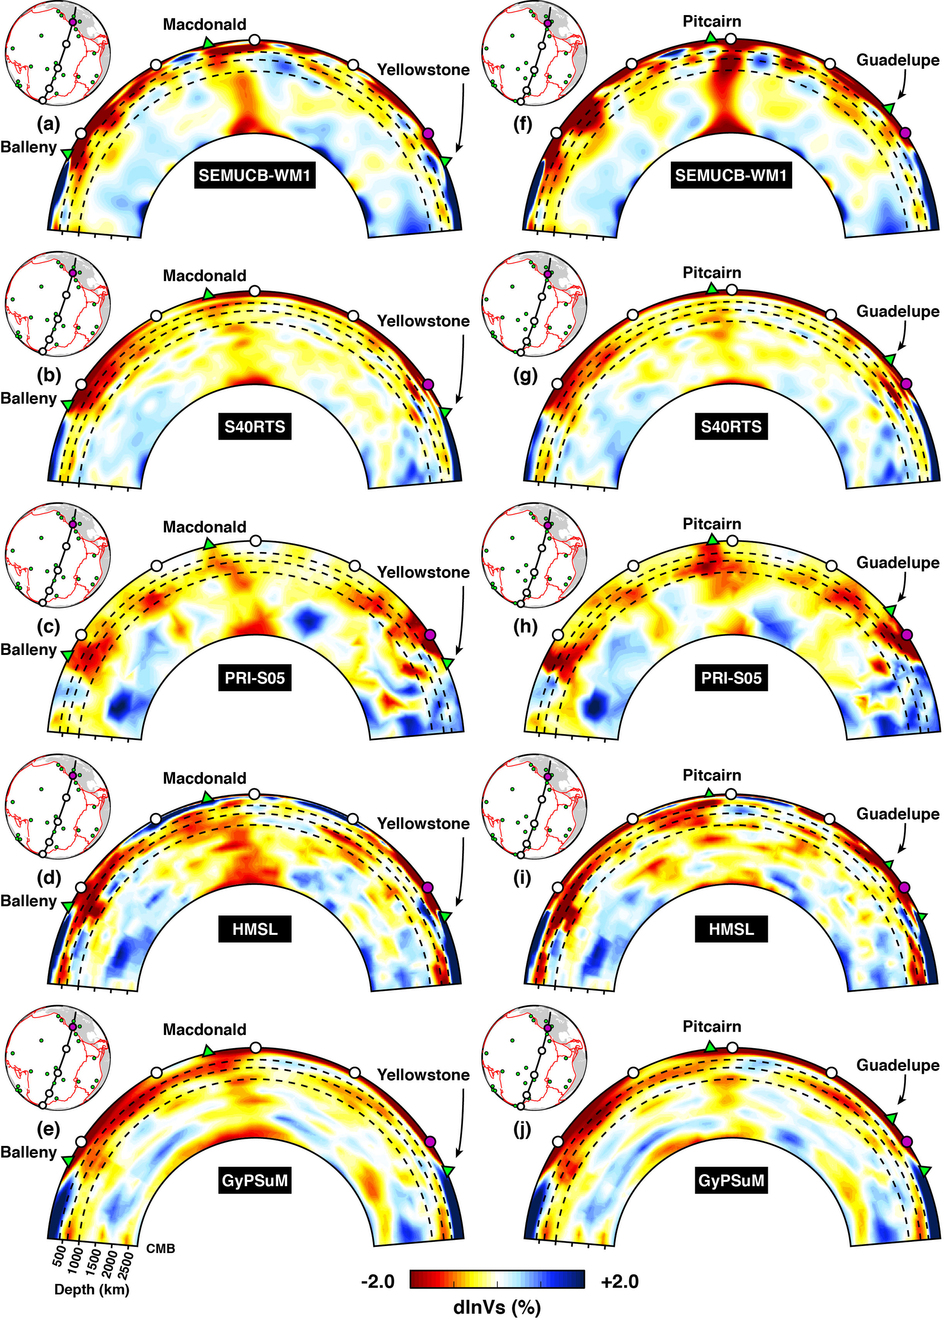<p style="font-size:90%;color:#444"><em>Shear wave speed anomalies in vertical sections through the Macdonald and Pitcairn hotspots in five tomographic models (French and Romanowicz 2015). Depth ticks at 500 km intervals.</em></p>

Assume that all variations of seismic wave speed are thermal. The maps show $\delta\ln v_s$, the *fractional* perturbation
of the shear-wave speed, $\delta v_s / v_s$, relative to a reference model at the same depth: a value of $-4$ per cent means
the wave speed there is 4 per cent lower than the reference. The $\delta$ is part of the symbol, not a quantity to be found,
and $\delta T$ likewise denotes the temperature anomaly. For this exercise use the conventional relations
$$ \delta T = -\frac{1}{\tilde\alpha}\,\delta\ln v_s, \qquad \eta = \eta_0\, e^{-\epsilon\,\delta T}, $$
with $\tilde\alpha = 2\times10^{-4}$ K$^{-1}$ (which combines the two steps of Lecture 22, the velocity-to-density and
density-to-temperature scalings), $\epsilon = 0.02$ K$^{-1}$, and a reference viscosity $\eta_0 = 5\times10^{20}$ Pa s.

**(a)** Estimate the temperature anomaly and the viscosity at 100 km depth beneath West and beneath East
Antarctica, and the Maxwell time of each. What is the likely cause of the temperature difference?

**(b)** Do the same for the lower-mantle part of the Pitcairn plume (take $\delta\ln v_s \approx -1.5$ per cent) and for a
subducted slab ($+1.5$ per cent), with $\eta_0 = 5\times10^{21}$ Pa s for the lower mantle. Why is this scaling crude,
and which conclusion survives its crudeness?

**(c)** Thwaites Glacier is losing ice at a rate that has changed over decades. Using your Maxwell times, say whether
the solid Earth beneath West and beneath East Antarctica responds elastically or viscously to such a change, and what
this implies for (i) the uplift rates that GPS should see, (ii) the stabilising feedback of Practical 21 question 2(c),
and (iii) the GIA corrections applied to satellite data over each region. GPS stations in the Amundsen Sea sector
measure uplift of about 4 cm yr$^{-1}$ (Barletta et al. 2018).